# 56 Face-detectability check

Render the anonymized mesh from a sweep of viewpoints and run the MediaPipe Face Detector on every view. For vertex deletion the expectation is a near-zero hit count; the residual hits characterise the privacy floor of the operator against an off-the-shelf detector.

Sweep: 21 viewpoints per subject (yaw $\in \{-90, -60, -30, 0, +30, +60, +90\}^\circ$, pitch $\in \{-20, 0, +20\}^\circ$) in the CTF frame, identical lighting and material across subjects. Confidence threshold left at the MediaPipe default ($0.5$).

**Cohort.** Iterates over the eleven valid thesis subjects: the optode-cap cohort S1--S7 (Subject 16--22) and the bare-cap cohort S8--S11 (Subject 12--15). Subject 11 is excluded (unusable acquisition). The output CSV carries the shared `s_id` and `optode` columns so the LaTeX table can render cohort membership and a per-cohort summary directly.

Populates §4.4.4 of the thesis (Table 4.7). The contact-sheet PNG is restricted to S2 (Subject 17) under the thesis data-sharing rule.

Output: `thesis_results_out/detectability_summary.csv`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve()))
from _thesis_helpers import (
    SUBJECTS, subject_paths, load_raw, load_anon, load_landmarks,
    run_pipeline, is_optode, s_id,
)

import numpy as np
import pandas as pd
import pyvista as pv
import cv2

# Render sweep configuration (matches the parameters described in §3 of
# the thesis): 21 viewpoints in the CTF frame, uniform grey material,
# neutral background. Detector confidence threshold is left at the
# MediaPipe default (0.5) inside the FaceDetectorOptions cell below.
WINDOW = (1024, 1024)
GREY = (180, 180, 180)
YAWS = list(range(-90, 91, 30))
PITCHES = (-20, 0, 20)

OUT_DIR = pathlib.Path('thesis_results_out')
OUT_DIR.mkdir(exist_ok=True)

## 1. Render sweep

Rotate the camera around the anonymized head in yaw/pitch, save each frame to disk so MediaPipe can read it.

In [2]:
from cedalion.vtktutils import trimesh_to_vtk_polydata



def render_sweep(surface, out_dir, subject_n):

    out_dir.mkdir(parents=True, exist_ok=True)

    poly = pv.wrap(trimesh_to_vtk_polydata(surface.mesh))

    files = []

    for yaw in YAWS:

        for pitch in PITCHES:

            pvplt = pv.Plotter(off_screen=True, window_size=WINDOW)

            pvplt.add_mesh(poly, color=[c/255 for c in GREY], smooth_shading=True)

            pvplt.set_background('white')

            pvplt.enable_anti_aliasing('ssaa')

            pvplt.view_xz()

            pvplt.camera.azimuth = 180 + yaw

            pvplt.camera.elevation = pitch

            pvplt.camera.zoom(1.3)

            fn = out_dir / f'subject{subject_n}_yaw{yaw:+04d}_pitch{pitch:+03d}.png'

            pvplt.screenshot(str(fn))

            pvplt.close()

            files.append((yaw, pitch, fn))

    return files

## 2. MediaPipe detector

Uses the short-range Face Detection model. Confidence threshold is left at the default 0.5; we also record the maximum confidence observed per view for the table.

In [3]:
import mediapipe as mp
from mediapipe.tasks import python as mp_py
from mediapipe.tasks.python import vision as mp_vision

# mediapipe 0.10+ dropped the legacy `mp.solutions.face_detection` namespace,
# so the notebook uses the Tasks API with the same BlazeFace short-range model.
MODEL_PATH = str((pathlib.Path('models') / 'blaze_face_short_range.tflite').resolve())

_fd_options = mp_vision.FaceDetectorOptions(
    base_options=mp_py.BaseOptions(model_asset_path=MODEL_PATH),
    min_detection_confidence=0.5,
)
_face_detector = mp_vision.FaceDetector.create_from_options(_fd_options)


def detect_faces(image_path):
    img = cv2.imread(str(image_path))
    if img is None:
        return 0, 0.0
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = _face_detector.detect(mp_img)
    if not result.detections:
        return 0, 0.0
    confidences = [d.categories[0].score for d in result.detections]
    return len(confidences), float(max(confidences))

I0000 00:00:1777385097.870382  100588 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1777385097.878943  100613 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 26.0.4-arch1.1), renderer: AMD Radeon Graphics (radeonsi, renoir, ACO, DRM 3.64, 6.19.11-arch1-1)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1777385097.884842  100590 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 3. Per-subject sweep + detection

In [4]:
view_root = OUT_DIR / 'detectability_views'

rows = []

for n in SUBJECTS:
    print(f'--- {s_id(n)} (Subject{n}) ---')

    if not subject_paths(n).anon_exists:

        print(f'skipping Subject{n}: no anon .obj')

        continue

    surface = load_anon(n)

    files = render_sweep(surface, view_root / f'subject{n}', n)

    hits = 0

    max_conf = 0.0

    n_views = len(files)

    for yaw, pitch, fn in files:

        k, c = detect_faces(fn)

        hits += int(k > 0)

        if c > max_conf:

            max_conf = c

    rows.append({

        's_id': s_id(n),
            'subject': n,
            'optode': is_optode(n),

        'n_views': n_views,

        'detector_hits': hits,

        'max_confidence': max_conf,

    })

    print(rows[-1])

--- S1 (Subject16) ---


{'s_id': 'S1', 'subject': 16, 'optode': True, 'n_views': 21, 'detector_hits': 4, 'max_confidence': 0.631351888179779}
--- S2 (Subject17) ---


{'s_id': 'S2', 'subject': 17, 'optode': True, 'n_views': 21, 'detector_hits': 0, 'max_confidence': 0.0}
--- S3 (Subject18) ---


{'s_id': 'S3', 'subject': 18, 'optode': True, 'n_views': 21, 'detector_hits': 2, 'max_confidence': 0.6622533202171326}
--- S4 (Subject19) ---


{'s_id': 'S4', 'subject': 19, 'optode': True, 'n_views': 21, 'detector_hits': 3, 'max_confidence': 0.5628886222839355}
--- S5 (Subject20) ---


...

{'s_id': 'S7', 'subject': 22, 'optode': True, 'n_views': 21, 'detector_hits': 3, 'max_confidence': 0.5641688704490662}
--- S8 (Subject12) ---


{'s_id': 'S8', 'subject': 12, 'optode': False, 'n_views': 21, 'detector_hits': 13, 'max_confidence': 0.6601899266242981}
--- S9 (Subject13) ---


{'s_id': 'S9', 'subject': 13, 'optode': False, 'n_views': 21, 'detector_hits': 5, 'max_confidence': 0.6651723384857178}
--- S10 (Subject14) ---


{'s_id': 'S10', 'subject': 14, 'optode': False, 'n_views': 21, 'detector_hits': 15, 'max_confidence': 0.7510956525802612}
--- S11 (Subject15) ---


{'s_id': 'S11', 'subject': 15, 'optode': False, 'n_views': 21, 'detector_hits': 10, 'max_confidence': 0.7277525663375854}


## 4. Summary + contact sheet

In [5]:
df = pd.DataFrame(rows)
if len(df):
    df = df.iloc[df['s_id'].map(lambda s: int(s[1:])).argsort()].reset_index(drop=True)
df

,s_id,subject,optode,n_views,detector_hits,max_confidence
0,S1,16,True,21,4,0.631352
1,S2,17,True,21,0,0.000000
2,S3,18,True,21,2,0.662253
3,S4,19,True,21,3,0.562889
4,S5,20,True,21,0,0.000000
5,S6,21,True,21,7,0.765164
6,S7,22,True,21,3,0.564169
7,S8,12,False,21,13,0.660190
8,S9,13,False,21,5,0.665172
9,S10,14,False,21,15,0.751096


Wrote thesis_results_out/detectability_contact.pdf


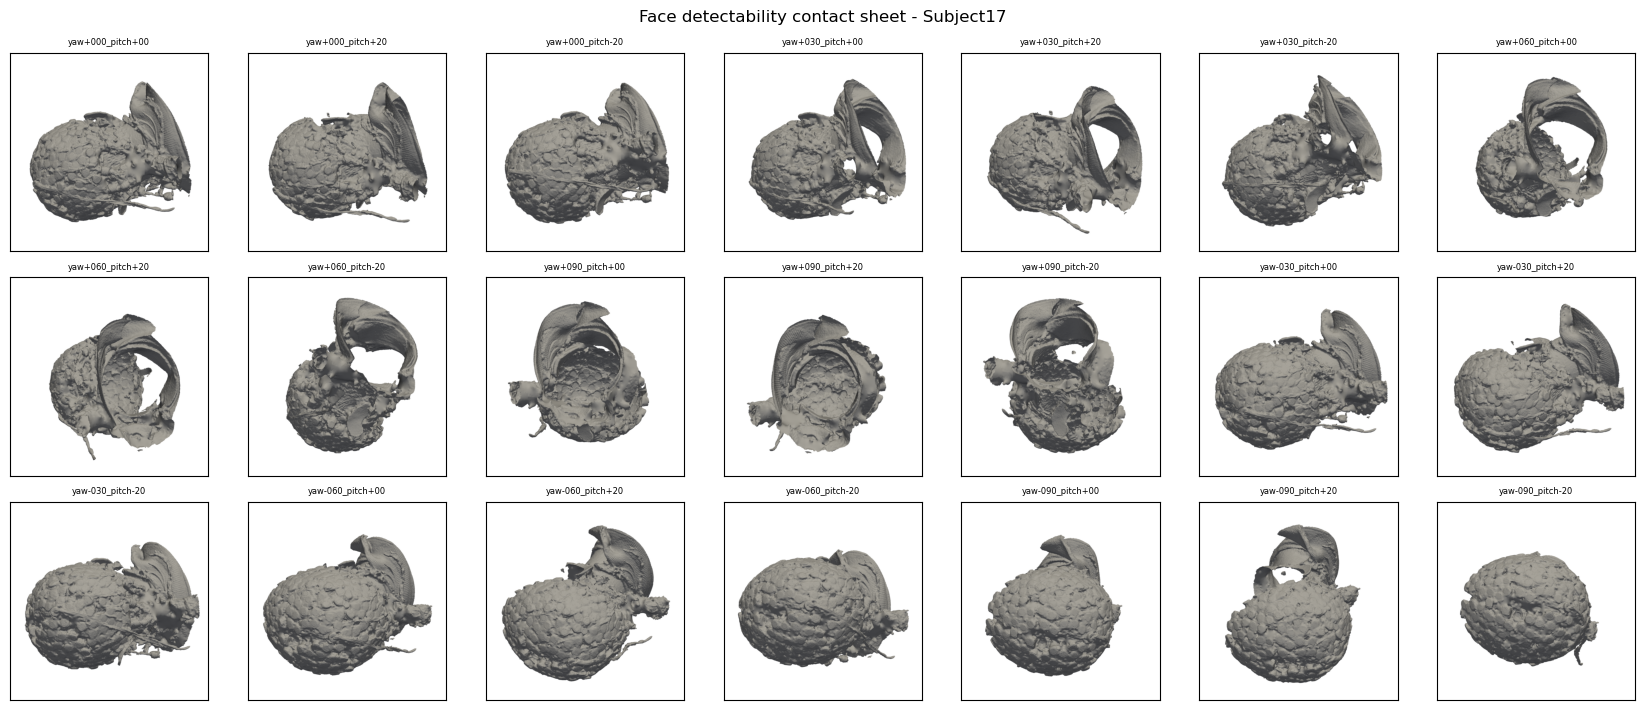

In [6]:
import matplotlib.pyplot as plt

import matplotlib.image as mpimg



# Thesis rule: only Subject 17 may appear in a rendered figure.

CONTACT_SUBJECT = 17 if 17 in list(df.subject) else None

if CONTACT_SUBJECT is not None:

    dir_ = view_root / f'subject{CONTACT_SUBJECT}'

    imgs = sorted(dir_.glob('*.png'))

    n_cols = 7

    n_rows = int(np.ceil(len(imgs) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.4*n_cols, 2.4*n_rows))

    for ax, img_path in zip(np.atleast_1d(axes).ravel(), imgs):

        ax.imshow(mpimg.imread(img_path))

        ax.set_xticks([]); ax.set_yticks([])

        ax.set_title(img_path.stem.split('_', 1)[1], fontsize=6)

    for ax in np.atleast_1d(axes).ravel()[len(imgs):]:

        ax.axis('off')

    fig.suptitle(f'Face detectability contact sheet - Subject{CONTACT_SUBJECT}')

    fig.tight_layout()

    out = OUT_DIR / 'detectability_contact.pdf'

    fig.savefig(out, dpi=200, bbox_inches='tight')

    print(f'Wrote {out}')

In [7]:
out_csv = OUT_DIR / 'detectability_summary.csv'

df.to_csv(out_csv, index=False)

print(f'Wrote {out_csv}')

Wrote thesis_results_out/detectability_summary.csv
